In [14]:
#----VIP-PLS-Spectra-SNV----#
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

from utils import datalodaer,preprocess

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 600,
    'svg.fonttype': 'none'
})
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [15]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

prep_obj = preprocess_methods["Detrend"]

In [16]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
image_features_path = project_root / 'data/pictures/lab_features.csv'
label_path = project_root / 'data/labels/5-HMF.csv'


In [17]:
def extract_all_feature_names(spectra_path, image_features_path):
    """
    提取并验证所有特征名称，包括合并后的完整特征列表
    
    参数:
        spectra_path (str): 光谱数据文件路径
        image_features_path (str): 图像特征数据文件路径
    
    返回:
        dict: 包含各种特征名称的字典
    """
    # 读取列名
    spectra_columns = pd.read_csv(spectra_path, nrows=0).columns.tolist()
    image_columns = pd.read_csv(image_features_path, nrows=0).columns.tolist()
    
    # 提取特征名称
    spectra_wavelengths = spectra_columns[2:]  # 跳过第一列（"名称"）
    image_feature_names = image_columns[1:]    # 跳过第一列（"名称"）
    
    # 验证光谱特征数量（可选）
    print(f"光谱特征数量: {len(spectra_wavelengths)}")
    print(f"图像特征数量: {len(image_feature_names)}")
    
    # 创建合并后的特征名称列表（模拟fused_data_split中的合并顺序）
    all_feature_names = spectra_wavelengths + image_feature_names
    
    return {
        'spectra_wavelengths': spectra_wavelengths,
        'image_feature_names': image_feature_names,
        'all_features': all_feature_names,
        'spectra_count': len(spectra_wavelengths),
        'image_count': len(image_feature_names),
        'total_features': len(all_feature_names)
    }

feature_names_dic = extract_all_feature_names(spectra_path, image_features_path)
all_features = feature_names_dic['all_features']
wavelength = feature_names_dic['spectra_wavelengths']
image_feature_names = feature_names_dic['image_feature_names']
image_count =feature_names_dic['image_count']
print(f'spectra_count: {feature_names_dic['spectra_count']}')
print(f'image_count: {feature_names_dic['image_count']}')
print(f'total_features: {feature_names_dic['total_features']}')


光谱特征数量: 2075
图像特征数量: 3
spectra_count: 2075
image_count: 3
total_features: 2078


In [18]:
# =========================================
# A. 数据融合处理 (关键步骤)
# =========================================
train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path,image_features_path,label_path)
# 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
spec_train_trans = prep_obj.fit_transform(train_set[0])
spec_val_trans = prep_obj.transform(val_set[0])
spec_test_trans = prep_obj.transform(test_set[0])

# 2. 图像特征部分: (StandardScaler在PLS内进行)
image_train_trans = train_set[1]
image_val_trans = val_set[1]
image_test_trans = test_set[1]

# 3. 特征级融合 (Concatenation)
X_train_fused = np.hstack([spec_train_trans, image_train_trans])
X_val_fused = np.hstack([spec_val_trans, image_val_trans])
X_test_fused = np.hstack([spec_test_trans, image_test_trans])

# 4. 构建数据元组
fused_train_set = (X_train_fused, train_set[2])
fused_val_set = (X_val_fused, val_set[2])
fused_test_set = (X_test_fused, test_set[2])

# 用于训练PLS
X2train = np.concatenate([fused_train_set[0], fused_val_set[0]], axis=0)
y2train = np.concatenate([fused_train_set[1], fused_val_set[1]], axis=0)


In [19]:
def compute_vip(pls, X, y):
    """
    pls: fitted sklearn.cross_decomposition.PLSRegression
    X: array (n_samples, p)
    y: array (n_samples,) or (n_samples, 1)
    """
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    T = pls.x_scores_          # (n, A)
    W = pls.x_weights_         # (p, A)
    Q = pls.y_loadings_        # (1, A) or (m, A)

    p, A = W.shape

    # SSY explained by each component a
    # SSY_a = sum_i (t_ia * q_a)^2
    # For single-response regression:
    SSY = np.sum((T @ Q.T) ** 2, axis=0)  # length A

    vip = np.zeros((p,))
    Wnorm2 = np.sum(W ** 2, axis=0)  # length A

    for j in range(p):
        vip[j] = np.sqrt(p * np.sum(SSY * (W[j, :] ** 2) / (Wnorm2 + 1e-12)) / (np.sum(SSY) + 1e-12))
    return vip

In [20]:
def train_and_compute_vip(X_train, y_train, n_components=13):
    """简单的训练和VIP计算组合"""
    # 1. 定义并训练Pipeline
    steps = [
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components))
    ]
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    
    # 2. 获取标准化后的数据和PLS模型
    X_scaled = pipe.named_steps["scaler"].transform(X_train)
    pls_model = pipe.named_steps["pls"]
    
    # 3. 计算VIP
    vip = compute_vip(pls_model, X_scaled, y_train)
    
    return pipe, vip


In [21]:
# 训练并计算VIP
trained_pipe, vip_scores = train_and_compute_vip(X2train, y2train, n_components=13)

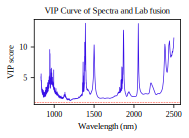

In [22]:
wavelengths_nm = np.array([float(c) for c in wavelength], dtype=float)
vip_threshold=1.0
title="VIP Curve of Spectra and Lab fusion"
outpath="02-VIP-PLS-Lab-Detrend.svg"

cm_to_inch = 1/2.54  # 厘米转英寸的转换因子
width_inch = 7 * cm_to_inch
height_inch = 5 * cm_to_inch

plt.figure(figsize=(width_inch, height_inch), dpi=600)
plt.plot(wavelengths_nm, vip_scores[:-image_count], linewidth=0.7,color="#3911E7")
plt.axhline(vip_threshold, linestyle="--", linewidth=0.5, color="#FD1702E0" )
plt.xlabel("Wavelength (nm)")
plt.ylabel("VIP score")
plt.title(title)
plt.tight_layout()
plt.savefig(outpath,
            format='svg',
            dpi=600,
            bbox_inches='tight')
plt.show()

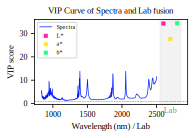

<Figure size 3840x2880 with 0 Axes>

In [23]:
def plot_vip_with_image_features(wavelengths, vip_scores, image_count, image_feature_names=None, 
                                  vip_threshold=1.0, title="VIP Curve", outpath="VIP-PLS-Lab-Detrend.svg"):
    """
    绘制光谱和图像特征的VIP得分图
    
    参数:
        wavelengths: 光谱波长列表或数组
        vip_scores: 所有特征的VIP得分数组（光谱+图像）
        image_count: 图像特征数量
        image_feature_names: 图像特征名称列表，可选
        vip_threshold: VIP阈值，默认1.0
        title: 图表标题
        outpath: 输出文件路径
    """
    # 分离光谱和图像的VIP得分
    spectra_vip = vip_scores[:-image_count]
    image_vip = vip_scores[-image_count:]
    
    # 将波长转换为数值数组
    if isinstance(wavelengths[0], str):
        wavelengths_nm = np.array([float(c) for c in wavelengths], dtype=float)
    else:
        wavelengths_nm = np.array(wavelengths, dtype=float)
    
    # 创建图像特征的x坐标（在波长之后继续）
    # 从最大波长值开始，每个图像特征间隔1个单位
    # max_wavelength = wavelengths_nm.max()
    # image_x_positions = np.arange(max_wavelength + 1, max_wavelength + 1 + image_count)
    image_x_positions = np.array([2600,2700,2800])
    
    # 创建x轴标签
    x_positions = np.concatenate([wavelengths_nm, image_x_positions])
    
    # 设置图形大小
    cm_to_inch = 1/2.54
    width_inch = 7 * cm_to_inch
    height_inch = 5 * cm_to_inch
    
    # 创建图形
    plt.figure(figsize=(width_inch, height_inch), dpi=600)
    
    # 绘制光谱部分的VIP曲线
    plt.plot(wavelengths_nm, spectra_vip, linewidth=0.7, color="#001BFF", label='Spectra')
    
    # 绘制图像部分的VIP散点
    # 使用不同的颜色和标记区分图像特征
    colors = np.array(["#FF009A","#FFE400","#00FF65"])
    image_feature_names = ["L*", "a*", "b*"]
    # 分别绘制每个图像特征
    for i in range(image_count):
        plt.scatter(
            image_x_positions[i],
            image_vip[i],
            s=10,
            color=colors[i],
            marker='s',
            alpha=0.8,
            label=image_feature_names[i],  # 每个单独label
            zorder=3
        )

    
    # 添加阈值线
    plt.axhline(vip_threshold, linestyle="--", linewidth=0.5, color="#FD1702E0")
    
    # 设置坐标轴标签
    plt.xlabel("Wavelength (nm) / Lab")
    plt.ylabel("VIP score")
    plt.title(title)
    
    # 添加图例
    plt.legend(loc='best', fontsize=6)
    
    # 标记图像特征区域
    # 在图像特征区域添加背景色
    image_start = image_x_positions.min() - 50
    image_end = image_x_positions.max() + 50
    y_min, y_max = plt.ylim()
    plt.axvspan(image_start, image_end, alpha=0.1, color='gray', 
                label='Image feature region')
    
    # 在x轴上标记图像特征区域
    plt.text((image_start + image_end) / 2, y_min - 0.1 * (y_max - y_min), 
             'Lab', ha='center', fontsize=8, color='gray')
    
    plt.tight_layout()
    plt.savefig(outpath, format='svg', dpi=600, bbox_inches='tight')
    plt.show()
    
    return plt.gcf()


# 创建基础版本（不带标签）
fig1 = plot_vip_with_image_features(
    wavelengths=wavelengths_nm,
    vip_scores=vip_scores,
    image_count=image_count,
    vip_threshold=vip_threshold,
    title=title,
    outpath="02-VIP-PLS-Lab-Detrend_1.svg"
)

/tmp/ipykernel_187489/1052244290.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


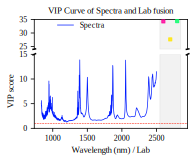

In [24]:
def plot_vip_with_image_features_broken_axis(
    wavelengths,
    vip_scores,
    image_count,
    image_feature_names=None,
    vip_threshold=1.0,
    title="VIP Curve",
    outpath="VIP-PLS-Lab-Detrend.svg"
):
    """
    带断轴的VIP曲线图（断开15~24）
    """

    spectra_vip = vip_scores[:-image_count]
    image_vip = vip_scores[-image_count:]

    wavelengths_nm = np.array(wavelengths, dtype=float)

    image_x_positions = np.array([2600, 2700, 2800])

    if image_feature_names is None:
        image_feature_names = ["L*", "a*", "b*"]

    colors = ["#FF009A", "#FFE400", "#00FF65"]

    # ==========================
    # 创建双轴（断轴）
    # ==========================
    cm_to_inch = 1/2.54
    width_inch = 7 * cm_to_inch
    height_inch = 5 * cm_to_inch
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True,
        figsize=(width_inch, height_inch),
        dpi=600,
        gridspec_kw={'height_ratios': [1, 2.5], "hspace": 0.1}
    )

    # ==========================
    # 绘图（上下轴都要画）
    # ==========================
    for ax in [ax_top, ax_bottom]:

        ax.plot(wavelengths_nm, spectra_vip,
                linewidth=0.7, color="#001BFF", label="Spectra")

        for i in range(image_count):
            ax.scatter(
                image_x_positions[i],
                image_vip[i],
                s=10,
                color=colors[i],
                marker='s',
                alpha=0.8,
                label=image_feature_names[i] if ax == ax_bottom else None,
                zorder=3
            )

        ax.axhline(vip_threshold, linestyle="--",
                   linewidth=0.5, color="#FD1702")

    # ==========================
    # 设置断轴范围
    # ==========================
    ax_bottom.set_ylim(0, 15)
    ax_top.set_ylim(24, 35)

    # 隐藏中间连接线
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)

    # ax_top.tick_params(labeltop=False)
    # 上图不显示 x 轴刻度和标签
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # 下图不显示顶部刻度
    ax_bottom.tick_params(axis='x', which='both', top=False)
    ax_bottom.xaxis.tick_bottom()

    # ==========================
    # 添加断裂符号
    # ==========================
    d = .008
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # ==========================
    # 图像区域阴影
    # ==========================
    image_start = image_x_positions.min() - 50
    image_end = image_x_positions.max() + 50

    for ax in [ax_top, ax_bottom]:
        ax.axvspan(image_start, image_end,
                   alpha=0.1, color='gray')

    # ==========================
    # 标签
    # ==========================
    ax_bottom.set_xlabel("Wavelength (nm) / Lab")
    ax_bottom.set_ylabel("VIP score")
    ax_top.set_title(title)

    # 仅底部轴放图例
    # ax_top.legend(fontsize=6, loc='upper left')

    ax_top.legend(
    loc="upper right",
    ncol=4,                 # 横排
    bbox_to_anchor=(0.5, 1.15),
    frameon=False
)
    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.savefig(outpath, format='svg', dpi=600, bbox_inches='tight')
    plt.show()

    return fig

fig1 = plot_vip_with_image_features_broken_axis(
    wavelengths=wavelengths_nm,
    vip_scores=vip_scores,
    image_count=3,
    vip_threshold=1.0,
    title=title,
    outpath="02-VIP-PLS-Lab-Detrend_2.svg"
)

In [25]:
def add_default_regions_nm(
    ax,
    regions=None,
    text_y=None,
    fontsize=6,
    color="#FD1702E0",
    x_is_wavenumber=False,
    draw_text=True
):
    if regions is None:
        if not x_is_wavenumber:
            regions = [
                (900, 1200, "(1)", 0.3),  # "2nd overtone (O–H/C–H)"
                (1350, 1500, "(2)", 0.5),  # "O–H (water)"
                (1870, 2020, "(3)", 0.4),  # "O–H combination (water)"
                (2100, 2350, "(4)", 0.3),  # "C–H/O–H/C–O combinations"
                # (2200, 2300, '', 0.6),
            ]
        else:
            regions = [
                (1e7/1200, 1e7/900,  "2nd overtone (O–H/C–H)", 0.10),
                (1e7/1500, 1e7/1350, "O–H (water)", 0.12),
                (1e7/2000, 1e7/1850, "O–H combination (water)", 0.12),
                (1e7/2350, 1e7/2100, "C–H/O–H/C–O combinations", 0.10),
            ]

    if draw_text:
        if text_y is None:
            y0, y1 = ax.get_ylim()
            text_y = y1 - 0.05 * (y1 - y0)

    for (x0, x1, lab, a) in regions:
        left, right = (x0, x1) if x0 < x1 else (x1, x0)
        ax.axvspan(left, right, alpha=a, color=color, linewidth=0, zorder=0)
        if draw_text:
            ax.text((left + right) / 2, text_y, lab,
                    ha="center", va="top", fontsize=fontsize, color="k")

/tmp/ipykernel_187489/4073267899.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


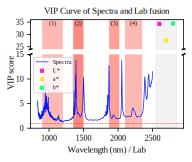

In [26]:
def plot_vip_with_image_features_broken_axis(
    wavelengths,
    vip_scores,
    image_count,
    image_feature_names=None,
    vip_threshold=1.0,
    title="VIP Curve",
    outpath="VIP-PLS-Lab-Detrend.svg"
):
    """
    带断轴的VIP曲线图（断开15~24）
    """

    spectra_vip = vip_scores[:-image_count]
    image_vip = vip_scores[-image_count:]

    wavelengths_nm = np.array(wavelengths, dtype=float)

    image_x_positions = np.array([2600, 2700, 2800])

    if image_feature_names is None:
        image_feature_names = ["L*", "a*", "b*"]

    colors = ["#FF009A", "#FFE400", "#00FF65"]

    # ==========================
    # 创建双轴（断轴）
    # ==========================
    cm_to_inch = 1/2.54
    width_inch = 7 * cm_to_inch
    height_inch = 5 * cm_to_inch
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True,
        figsize=(width_inch, height_inch),
        dpi=600,
        gridspec_kw={'height_ratios': [1, 2.5], "hspace": 0.1}
    )

    # ==========================
    # 绘图（上下轴都要画）
    # ==========================
    for ax in [ax_top, ax_bottom]:

        ax.plot(wavelengths_nm, spectra_vip,
                linewidth=0.7, color="#001BFF", label="Spectra")

        for i in range(image_count):
            ax.scatter(
                image_x_positions[i],
                image_vip[i],
                s=10,
                color=colors[i],
                marker='s',
                alpha=0.8,
                label=image_feature_names[i] if ax == ax_bottom else None,
                zorder=3
            )

        ax.axhline(vip_threshold, linestyle="--",
                   linewidth=0.5, color="#FD1702")

    # ==========================
    # 设置断轴范围
    # ==========================
    ax_bottom.set_ylim(0, 15)
    ax_top.set_ylim(24, 36)

    # 隐藏中间连接线
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)

    # ax_top.tick_params(labeltop=False)
    # 上图不显示 x 轴刻度和标签
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # 下图不显示顶部刻度
    ax_bottom.tick_params(axis='x', which='both', top=False)
    ax_bottom.xaxis.tick_bottom()

    # ==========================
    # 添加断裂符号
    # ==========================
    d = .008
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # ==========================
    # 图像区域阴影
    # ==========================
    image_start = image_x_positions.min() - 50
    image_end = image_x_positions.max() + 50

    for ax in [ax_top, ax_bottom]:
        ax.axvspan(image_start, image_end,
                   alpha=0.1, color='gray')

    # ==========================
    # 标签
    # ==========================
    ax_bottom.set_xlabel("Wavelength (nm) / Lab")
    ax_bottom.set_ylabel("VIP score")
    ax_bottom.yaxis.set_label_coords(-0.1, 0.75)  # 向上移动
    ax_top.set_title(title)
    # [ADD] 画完曲线、并 set_ylim 之后调用（这样 text_y 才能基于最终ylim定位）
    add_default_regions_nm(ax_top, regions=None, draw_text=True)   # 上轴只阴影
    add_default_regions_nm(ax_bottom, regions=None, draw_text=False)    # 下轴阴影+文字

    # # 仅底部轴放图例
    ax_bottom.legend(fontsize=6, 
                     loc='upper left',
                     )
    # 设置更详细的边框样式
    # ax_bottom.legend(fontsize=6, 
    #                 loc='upper left',
    #                 frameon=True,
    #                 edgecolor="#353434",      # 使用十六进制颜色
    #                 # linewidth=1.0,            # 边框线宽
    #                 fancybox=True,           # 直角边框
    #                 framealpha=0.7,           # 完全不透明
    #                 facecolor='white',        # 背景颜色
    #                 borderpad=0.5,            # 内部边距
    #                 labelspacing=0.5,         # 标签间距
    #                 borderaxespad=0.5)        # 与坐标轴的间距

    # ax_top.legend(
    #     loc="upper right",
    #     ncol=4,                 # 横排
    #     bbox_to_anchor=(0.5, 1.15),
    #     frameon=False
    # )

    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.savefig(outpath, format='svg', dpi=600, bbox_inches='tight')
    plt.show()

    return fig


fig1 = plot_vip_with_image_features_broken_axis(
    wavelengths=wavelengths_nm,
    vip_scores=vip_scores,
    image_count=3,
    vip_threshold=1.0,
    title=title,
    outpath="02-VIP-PLS-Lab-Detrend_3.svg"
)